# MDR-TS v14.1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v14.1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

Added spatial features to the split


For other info see `MDR-TS-v1.0`

## Imports

In [34]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.inspection import permutation_importance

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## Environment Setup

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## Data Access

In [3]:
# Project paths
VERSION = "v14"
SUBVERSION = "v14.1"
RUN_NAME = "mdr_ts_v14_1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v14/v14.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## Data Loading

In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_with_spatial/train_plus_static.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_with_spatial/val_plus_static.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_with_spatial/test_plus_static.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_with_spatial/train_plus_static.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_with_spatial/val_plus_static.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_with_spatial/test_plus_static.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 406

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'soil_moisture_5cm', 'D_sin_DOY', 'D_cos_DOY', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1']


## Data Sanity Checks

In [6]:
TARGET_COL = "soil_moisture_5cm"
KEEP_META_COLS = ["station_id", "date", "latitude", "longitude"]

FAMILIES = {
    "A_dyn": ("A_",),
    "B_vol": ("V_", "B_"),
    "C_mem": ("C_",),
    "D_sea": ("D_",),
    "E_radar": ("E_",),
    "F_opt": ("F_",),
    "G_met": ("G_",),
    "H_coup": ("H_",),
    "I_evt": ("I_",),
    "J_geo": ("J_",),
    "K_geo_derived": ("K_",),
}

FEATURE_COLS = [
    c for c in train_df.columns
    if c not in KEEP_META_COLS + [TARGET_COL]
]

In [7]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[WARN] station Touchet_WA_824: missing split data (train=3311, val=0, test=170)

[WARNING] 1 station(s) have temporal leakage or split issues.


In [8]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Touchet_WA_824:
    train max date: 2020-10-28 00:00:00
    val   min date: NaT


## Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     16972
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2829
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [10]:
# encode land-cover since it's of type string and not numeric
print("Unique landcover_label (train):")
print(sorted(train_df["landcover_label"].dropna().unique()))
print("Count:", train_df["landcover_label"].nunique())

Unique landcover_label (train):
['Grassland', 'Tree cover']
Count: 2


```yaml
1: Grassland
2: Tree cover
```

In [11]:
landcover_map = {
    "Grassland": 1,
    "Tree cover": 2,
}

def encode_landcover(df):
    df = df.copy()
    df["landcover_encoded"] = df["landcover_label"].map(landcover_map).fillna(0).astype(int)
    return df

train_df = encode_landcover(train_df)
val_df   = encode_landcover(val_df)
test_df  = encode_landcover(test_df)

FEATURE_COLS.append("landcover_encoded")

for df in (train_df, val_df, test_df):
    if "landcover_label" in df.columns:
        df.drop(columns=["landcover_label"], inplace=True)

## Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

In [12]:
XGB_PARAMS = dict(
    n_estimators=4000,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.75,
    gamma=0.0,
    reg_alpha=0.05,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
)

In [19]:
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse,
        "R2": float(r2_score(y_true, y_pred)),
    }

def get_feature_cols(df, meta_cols, target_col):
    return [c for c in df.columns if c not in (list(meta_cols) + [target_col])]

def drop_family(cols, prefixes):
    return [c for c in cols if not any(c.startswith(p) for p in prefixes)]

def prepare_xy(df, feature_cols, target_col):
    d = df.dropna(subset=[target_col]).copy()
    X = d[feature_cols].apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(d[target_col], errors="coerce")
    mask = (~y.isna()) & (~X.isna().any(axis=1))
    return X.loc[mask], y.loc[mask]

In [14]:
full_cols = get_feature_cols(train_df, KEEP_META_COLS, TARGET_COL)

prefixes_to_check = sorted(set(p for v in FAMILIES.values() for p in v))
counts = []
for p in prefixes_to_check:
    counts.append({"prefix": p, "n_cols": sum(c.startswith(p) for c in full_cols)})

prefix_df = pd.DataFrame(counts).sort_values("n_cols", ascending=False)
prefix_df

,prefix,n_cols
11,V_,168
0,A_,80
2,C_,56
9,J_,43
3,D_,14
4,E_,7
6,G_,6
10,K_,6
7,H_,4
5,F_,3


In [15]:
feature_sets = {"FULL": full_cols}

for fam_name, fam_prefixes in FAMILIES.items():
    feature_sets[f"DROP_{fam_name}"] = drop_family(full_cols, fam_prefixes)

feat_sizes = pd.DataFrame({
    "variant": list(feature_sets.keys()),
    "n_features": [len(v) for v in feature_sets.values()]
}).sort_values("n_features", ascending=False)

feat_sizes

,variant,n_features
0,FULL,401
9,DROP_I_evt,400
6,DROP_F_opt,398
8,DROP_H_coup,397
7,DROP_G_met,395
11,DROP_K_geo_derived,395
5,DROP_E_radar,394
4,DROP_D_sea,387
10,DROP_J_geo,358
3,DROP_C_mem,345


In [16]:
# convert edge cases (inf/-inf) to NaN and let XGB treat them as missing

def clean_inf(df, feature_cols):
    df = df.copy()
    df[feature_cols] = (
        df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
    )
    return df

train_df = clean_inf(train_df, feature_sets["FULL"])
val_df   = clean_inf(val_df,   feature_sets["FULL"])
test_df  = clean_inf(test_df,  feature_sets["FULL"])

In [17]:
def train_eval_variant(tag, feature_cols):
    Xtr, ytr = prepare_xy(train_df, feature_cols, TARGET_COL)
    Xva, yva = prepare_xy(val_df, feature_cols, TARGET_COL)
    Xte, yte = prepare_xy(test_df, feature_cols, TARGET_COL)

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(Xtr, ytr)

    pred_tr = model.predict(Xtr)
    pred_va = model.predict(Xva)
    pred_te = model.predict(Xte)

    out = {
        "tag": tag,
        "n_features": int(len(feature_cols)),
        "rows_train": int(len(Xtr)),
        "rows_val": int(len(Xva)),
        "rows_test": int(len(Xte)),
        "train": metrics(ytr, pred_tr),
        "val": metrics(yva, pred_va),
        "test": metrics(yte, pred_te),
    }

    # return preds too for plots
    return out, (ytr, pred_tr), (yva, pred_va), (yte, pred_te), model

In [20]:
full_res, (ytr, ptr), (yva, pva), (yte, pte), full_model = train_eval_variant("FULL", feature_sets["FULL"])
full_res

{'tag': 'FULL',
 'n_features': 401,
 'rows_train': 7483,
 'rows_val': 2025,
 'rows_test': 1980,
 'train': {'MAE': 0.0009803253557076222,
  'RMSE': 0.0014179636898722298,
  'R2': 0.9997992488845542},
 'val': {'MAE': 0.03648224024747625,
  'RMSE': 0.04632926824341752,
  'R2': 0.7901058294882475},
 'test': {'MAE': 0.04507124823997117,
  'RMSE': 0.05695116945796764,
  'R2': 0.6370543603728371}}

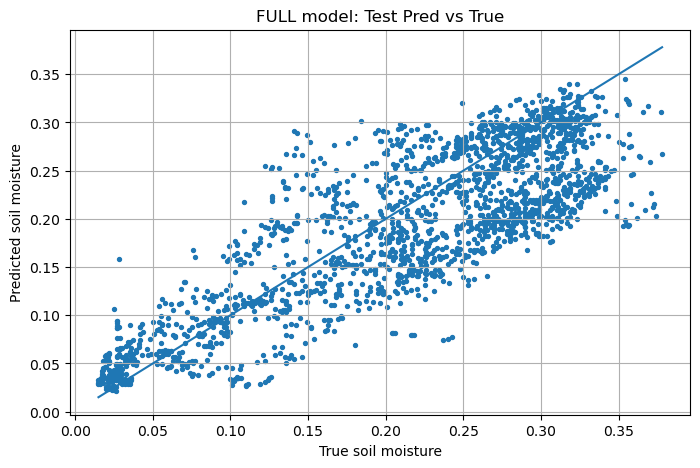

In [21]:
plt.figure()
plt.scatter(yte, pte, s=8)
mn = float(min(yte.min(), pte.min()))
mx = float(max(yte.max(), pte.max()))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("True soil moisture")
plt.ylabel("Predicted soil moisture")
plt.title("FULL model: Test Pred vs True")
plt.show()

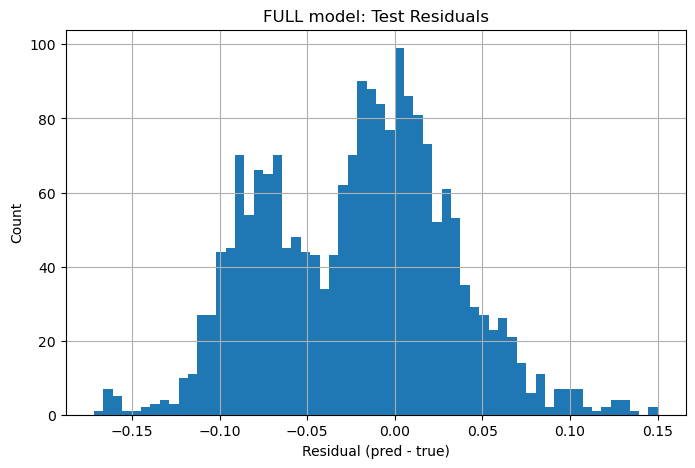

Test residual mean: -0.02159307191263546
Test residual std: 0.05269890841379828


In [22]:
resid = (pte - yte.values)

plt.figure()
plt.hist(resid, bins=60)
plt.xlabel("Residual (pred - true)")
plt.ylabel("Count")
plt.title("FULL model: Test Residuals")
plt.show()

print("Test residual mean:", float(np.mean(resid)))
print("Test residual std:", float(np.std(resid)))

In [23]:
results = []
preds_test = {}

base_test_r2 = full_res["test"]["R2"]
results.append({**full_res, "delta_test_R2": 0.0})

for tag, cols in feature_sets.items():
    if tag == "FULL":
        continue
    res, _, _, (yte_i, pte_i), _ = train_eval_variant(tag, cols)
    res["delta_test_R2"] = float(res["test"]["R2"] - base_test_r2)
    results.append(res)
    preds_test[tag] = (yte_i.values, pte_i)

summary = pd.DataFrame([{
    "tag": r["tag"],
    "n_features": r["n_features"],
    "train_R2": r["train"]["R2"],
    "val_R2": r["val"]["R2"],
    "test_R2": r["test"]["R2"],
    "delta_test_R2": r["delta_test_R2"],
    "test_MAE": r["test"]["MAE"],
    "test_RMSE": r["test"]["RMSE"],
} for r in results])

summary = summary.sort_values("delta_test_R2")
summary

,tag,n_features,train_R2,val_R2,test_R2,delta_test_R2,test_MAE,test_RMSE
4,DROP_D_sea,387,0.999792,0.784626,0.633252,-0.003802,0.045347,0.057249
6,DROP_F_opt,398,0.999798,0.790287,0.633796,-0.003259,0.045561,0.057206
11,DROP_K_geo_derived,395,0.999801,0.783689,0.635326,-0.001728,0.045037,0.057087
8,DROP_H_coup,397,0.999807,0.798945,0.636204,-0.000851,0.044491,0.056413
5,DROP_E_radar,394,0.999801,0.786042,0.636312,-0.000742,0.045620,0.057009
0,FULL,401,0.999799,0.790106,0.637054,0.000000,0.045071,0.056951
9,DROP_I_evt,400,0.999800,0.790166,0.639687,0.002633,0.045183,0.056744
1,DROP_A_dyn,321,0.999772,0.786637,0.640250,0.003195,0.045250,0.056700
3,DROP_C_mem,345,0.999793,0.791650,0.647180,0.010125,0.044484,0.056151
2,DROP_B_vol,233,0.999755,0.786496,0.647721,0.010667,0.044050,0.056108


In [24]:
rank_df = summary[summary["tag"] != "FULL"].copy()
rank_df["family"] = rank_df["tag"].str.replace("DROP_", "", regex=False)
rank_df = rank_df.sort_values("delta_test_R2")
rank_df[["family", "delta_test_R2", "test_R2", "n_features"]]

,family,delta_test_R2,test_R2,n_features
4,D_sea,-0.003802,0.633252,387
6,F_opt,-0.003259,0.633796,398
11,K_geo_derived,-0.001728,0.635326,395
8,H_coup,-0.000851,0.636204,397
5,E_radar,-0.000742,0.636312,394
9,I_evt,0.002633,0.639687,400
1,A_dyn,0.003195,0.640250,321
3,C_mem,0.010125,0.647180,345
2,B_vol,0.010667,0.647721,233
7,G_met,0.010901,0.647955,395


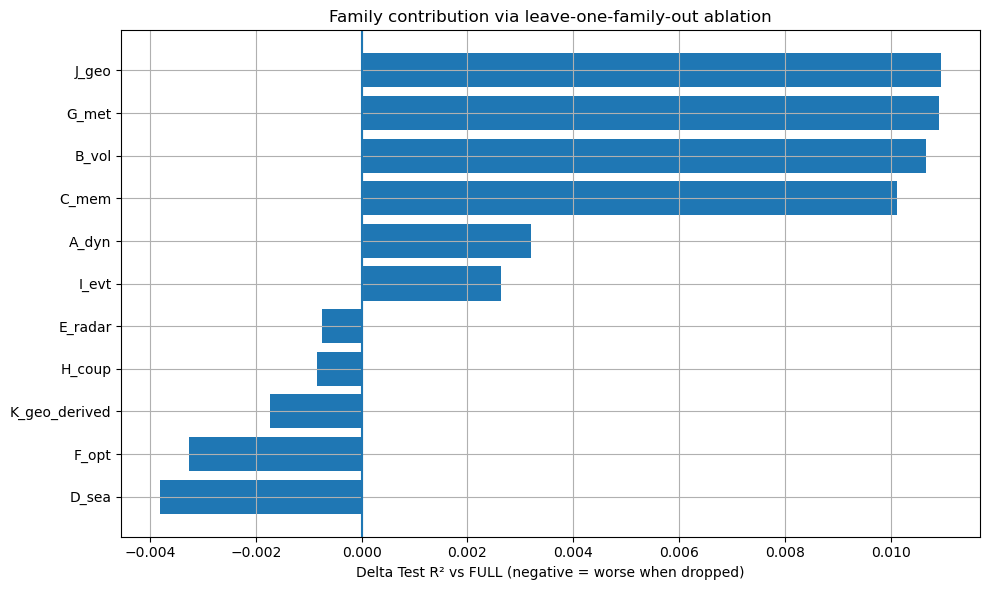

In [25]:
plot_df = rank_df.sort_values("delta_test_R2")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["family"], plot_df["delta_test_R2"])
plt.axvline(0.0)
plt.xlabel("Delta Test R² vs FULL (negative = worse when dropped)")
plt.title("Family contribution via leave-one-family-out ablation")
plt.tight_layout()
plt.show()

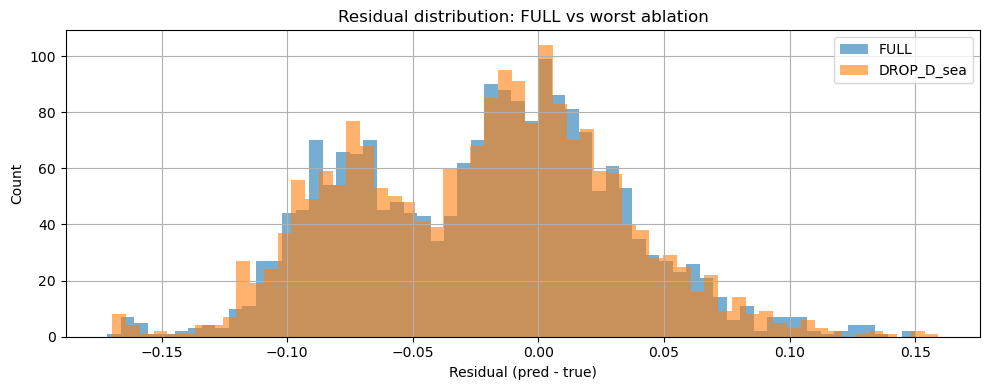

Worst ablation tag: DROP_D_sea


In [26]:
worst = plot_df.iloc[0]["tag"]  # most negative delta
y_w, p_w = preds_test[worst]

plt.figure(figsize=(10, 4))
plt.hist((pte - yte.values), bins=60, alpha=0.6, label="FULL")
plt.hist((p_w - y_w), bins=60, alpha=0.6, label=worst)
plt.xlabel("Residual (pred - true)")
plt.ylabel("Count")
plt.title("Residual distribution: FULL vs worst ablation")
plt.legend()
plt.tight_layout()
plt.show()

print("Worst ablation tag:", worst)

In [31]:
booster = full_model.get_booster()

importance_dict = booster.get_score(importance_type="gain")

imp_df = (
    pd.DataFrame({
        "feature": list(importance_dict.keys()),
        "gain": list(importance_dict.values())
    })
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

top50 = imp_df.head(5)

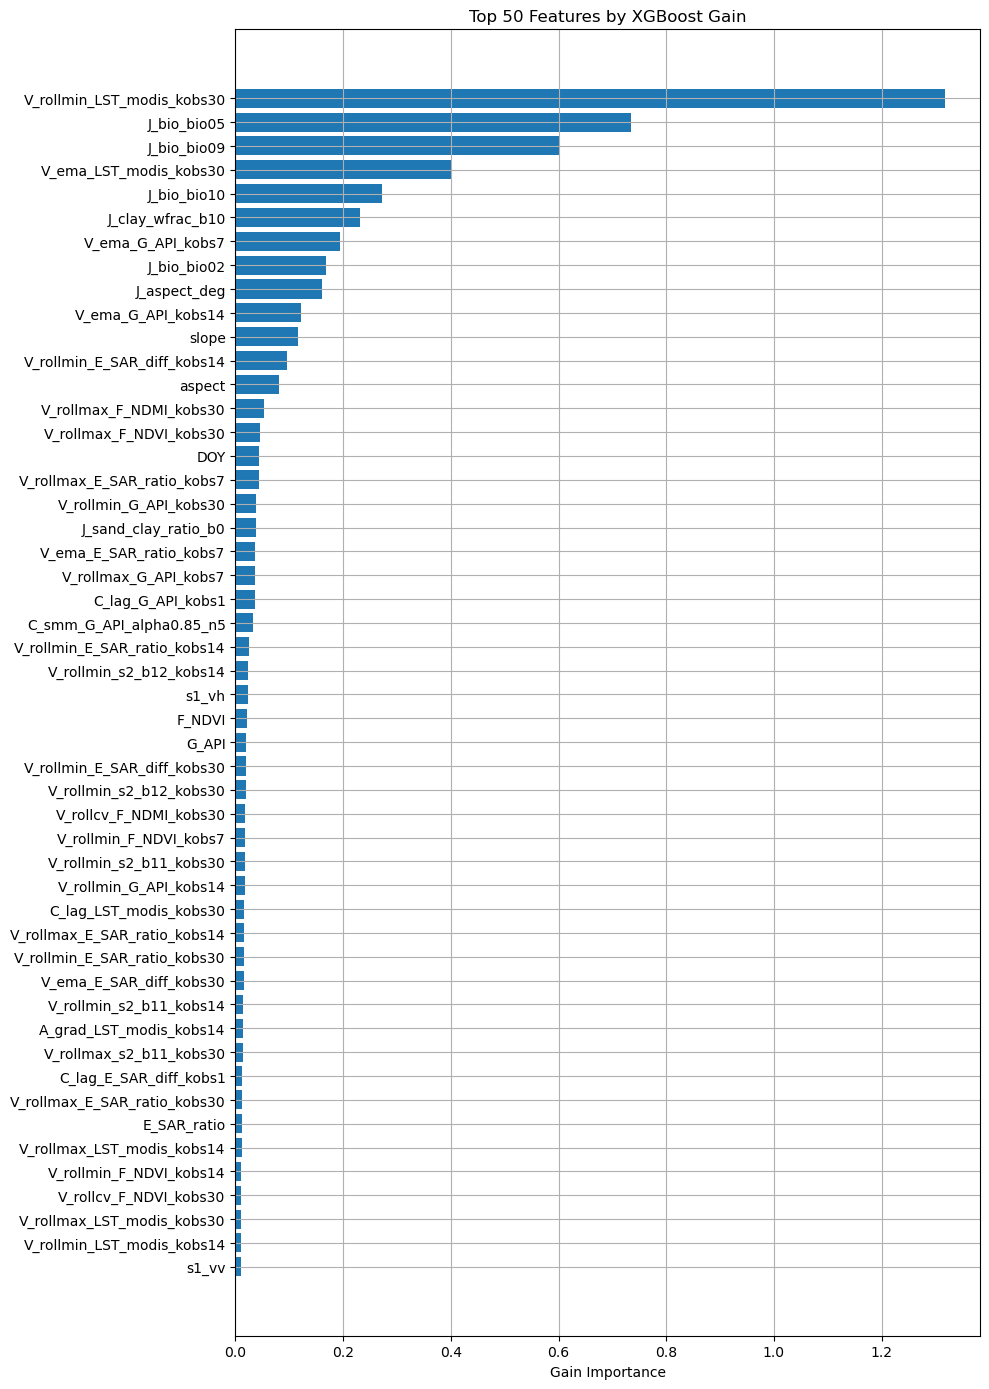

In [30]:
plt.figure(figsize=(10, 14))
plt.barh(top50["feature"][::-1], top50["gain"][::-1])
plt.title("Top 50 Features by XGBoost Gain")
plt.xlabel("Gain Importance")
plt.tight_layout()
plt.show()

In [42]:
imp_df["gain_norm"] = imp_df["gain"] / imp_df["gain"].sum()

top50 = imp_df.head(60)
top50.to_csv(
    "/Users/jbalkovec/Desktop/MDR/Models/Temporal/v14/v14.1/top50_permutation_importance.csv",
    index=False
)

In [33]:
used_features = set(imp_df["feature"])
unused = set(FEATURE_COLS) - used_features
len(unused)

38

In [38]:
Xtr, ytr = prepare_xy(train_df, feature_sets["FULL"], TARGET_COL)
Xva, yva = prepare_xy(val_df, feature_sets["FULL"], TARGET_COL)
Xte, yte = prepare_xy(test_df, feature_sets["FULL"], TARGET_COL)

In [39]:
TOPK = 60
topk_features = imp_df["feature"].head(TOPK).tolist()

perm = permutation_importance(
    full_model,
    Xva,
    yva,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

perm_df = pd.DataFrame({
    "feature": topk_features,
    "perm_mean": perm.importances_mean,
    "perm_std": perm.importances_std,
}).sort_values("perm_mean", ascending=False)

perm_df.head(50)

KeyboardInterrupt: 

In [ ]:
top50_perm = perm_df.head(50)

plt.figure(figsize=(10, 14))
plt.barh(top50_perm["feature"][::-1], top50_perm["importance"][::-1])
plt.title("Top 50 Features by Validation Permutation Importance")
plt.xlabel("Delta R² impact")
plt.tight_layout()
plt.show()

---

_Jakob Balkovec_